# Exploratory Data Analysis (EDA) Visualization

## Dataset

This notebook uses the Titanic dataset: `Titanic-Dataset.csv`.

Exploratory Data Analysis (EDA) visualization helps us understand the data through meaningful graphs. Each visualization is selected based on the type of variable or relationship being analyzed.

The main objective is not simply to create graphs, but to use each visualization to identify useful patterns, distributions, relationships, and potential issues in the data.

## Visualization Tools

- **Matplotlib** is used for creating and customizing visualizations.
- **Seaborn** is used for creating statistical and attractive visualizations.

## AI/ML Relevance

Visual exploration helps us understand feature distributions, outliers, relationships, correlations, and possible feature importance before building a Machine Learning model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Titanic-Dataset.csv")

sns.set_theme(style="whitegrid")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Histogram

### Concept

A histogram shows how numerical values are distributed across different intervals or ranges.

### Example

In the Titanic dataset, the `Age` column can be visualized using a histogram to understand the age distribution of passengers.

### Why This Visualization Was Selected

A histogram is suitable because `Age` is a continuous numerical variable.

### Implementation

We use a histogram to visualize the frequency of passenger ages.

### Output

The graph shows how many passengers fall within different age ranges.

### Interpretation

The distribution helps us identify the most common age groups and understand whether the ages are evenly distributed or concentrated in certain ranges.

### Insight

The Titanic dataset contains passengers from different age groups, with some age ranges appearing more frequently than others.

### AI/ML Relevance

Understanding the distribution of numerical features helps identify skewness, missing patterns, and possible preprocessing requirements.

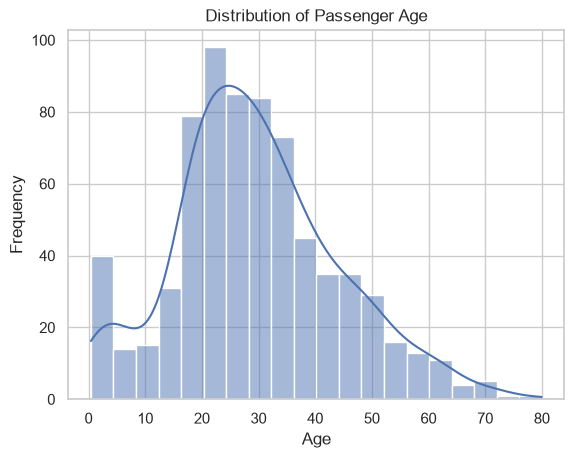

In [2]:
sns.histplot(df["Age"].dropna(), bins=20, kde=True)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## 2. Box Plot

### Concept

A box plot summarizes the distribution of a numerical variable using the median, quartiles, spread, and possible outliers.

### Example

The `Fare` column can be analyzed using a box plot.

### Why This Visualization Was Selected

A box plot is useful for identifying extreme values and understanding the spread of a numerical variable.

### Implementation

We use a box plot to examine the distribution of passenger fares.

### Output

The graph displays the median, quartiles, and possible outliers in the `Fare` variable.

### Interpretation

Values located far from the main box may represent unusual or extreme fare values.

### Insight

The `Fare` variable may contain some high-value observations compared with most passenger fares.

### AI/ML Relevance

Outliers can influence some Machine Learning models and may require further investigation or transformation.

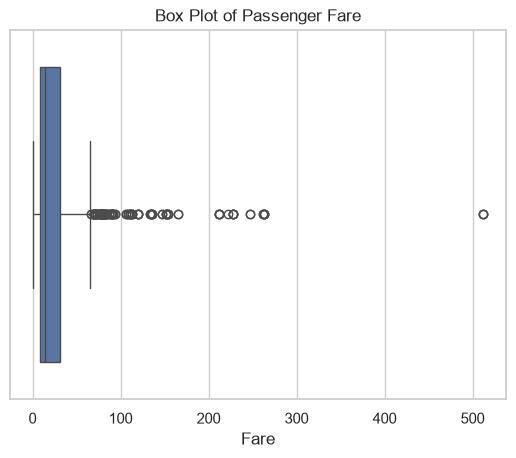

In [3]:
sns.boxplot(x=df["Fare"])

plt.title("Box Plot of Passenger Fare")
plt.xlabel("Fare")
plt.show()

## 3. Bar Chart

### Concept

A bar chart compares values across different categories.

### Example

We can calculate the average survival rate for each passenger class using a bar chart.

### Why This Visualization Was Selected

Passenger class is a categorical variable, while the average survival rate is a numerical value. A bar chart clearly compares these values.

### Implementation

We calculate the mean survival rate for each `Pclass`.

### Output

Each bar represents the average survival rate of a passenger class.

### Interpretation

A higher bar indicates a higher average survival rate for that passenger class.

### Insight

The visualization helps identify whether passenger class was related to survival.

### AI/ML Relevance

Relationships between categorical features and the target variable can help identify potentially useful predictive features.

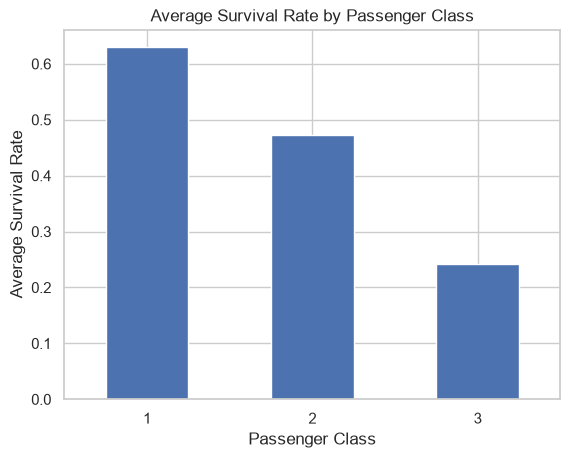

In [4]:
survival_by_class = df.groupby("Pclass")["Survived"].mean()

survival_by_class.plot(kind="bar")

plt.title("Average Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Survival Rate")
plt.xticks(rotation=0)
plt.show()

## 4. Count Plot

### Concept

A count plot shows the number of observations in each category.

### Example

The `Sex` column can be analyzed to compare the number of male and female passengers.

### Why This Visualization Was Selected

A count plot is appropriate for categorical variables when we want to compare category frequencies.

### Implementation

We count the number of passengers in each category of the `Sex` column.

### Output

Each bar represents the number of passengers belonging to a particular category.

### Interpretation

The graph shows whether one category contains more observations than another.

### Insight

The dataset contains different numbers of male and female passengers.

### AI/ML Relevance

Category imbalance may influence feature relationships and should be understood before encoding and model development.

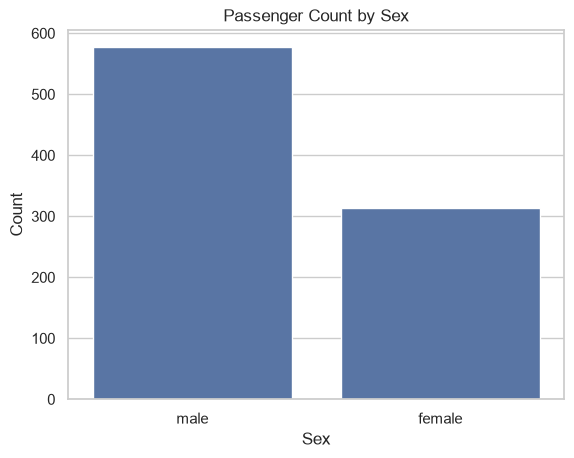

In [5]:
sns.countplot(data=df, x="Sex")

plt.title("Passenger Count by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

## 5. Scatter Plot

### Concept

A scatter plot shows the relationship between two numerical variables.

### Example

We can compare passenger `Age` and `Fare`.

### Why This Visualization Was Selected

A scatter plot helps identify patterns, clusters, and possible relationships between two numerical variables.

### Implementation

We plot `Age` against `Fare`.

### Output

Each point represents an individual passenger with available age and fare information.

### Interpretation

The position of the points helps us examine whether age and fare show a clear relationship.

### Insight

If the points are widely scattered, the relationship between the two variables is likely weak.

### AI/ML Relevance

Understanding relationships between numerical features helps identify useful features and possible feature interactions.

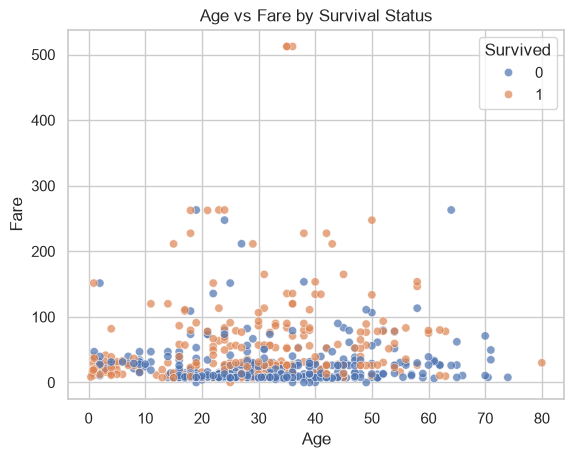

In [6]:
sns.scatterplot(data=df, x="Age", y="Fare", hue="Survived", alpha=0.7)

plt.title("Age vs Fare by Survival Status")
plt.show()

## 6. Line Plot

### Concept

A line plot is useful for showing how a numerical value changes across an ordered variable.

### Example

Passenger class is an ordered variable, so we can visualize the average survival rate across the three passenger classes.

### Why This Visualization Was Selected

A line plot helps show the overall trend in survival rate from first class to third class.

### Implementation

We calculate the mean value of `Survived` for each passenger class.

### Output

The line connects the average survival rates across the ordered passenger classes.

### Interpretation

Changes in the line indicate how survival rates vary across passenger classes.

### Insight

The visualization makes the trend between passenger class and survival easier to observe.

### AI/ML Relevance

Feature trends can reveal relationships that may be useful when selecting and engineering features for Machine Learning.

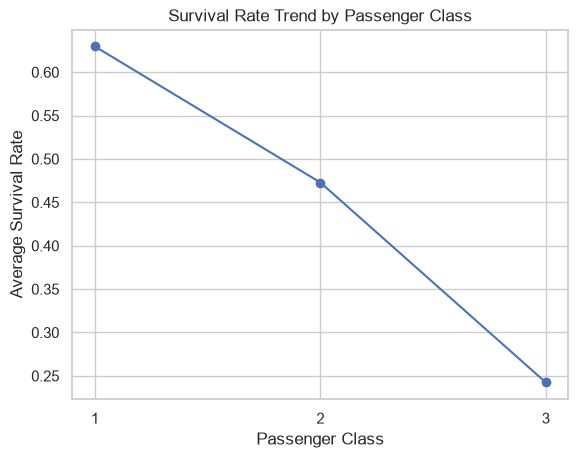

In [7]:
survival_trend = df.groupby("Pclass")["Survived"].mean().sort_index()

plt.plot(survival_trend.index, survival_trend.values, marker="o")

plt.title("Survival Rate Trend by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Survival Rate")
plt.xticks([1, 2, 3])
plt.show()

## 7. Violin Plot

### Concept

A violin plot combines information about data distribution and data spread.

### Example

We can compare the age distribution of passengers who survived and those who did not survive.

### Why This Visualization Was Selected

A violin plot is useful for comparing the distribution of a numerical variable across different categories.

### Implementation

We compare `Age` across the two categories of the `Survived` variable.

### Output

The width of each violin represents the concentration of observations at different age values.

### Interpretation

Differences in shape and spread can show whether the age distributions differ between survivors and non-survivors.

### Insight

The visualization helps investigate whether age may have been related to survival.

### AI/ML Relevance

Comparing feature distributions across target classes can help identify potentially useful predictive relationships.

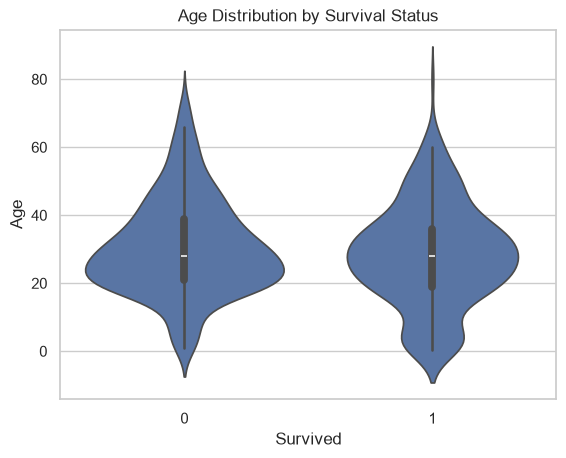

In [8]:
sns.violinplot(data=df, x="Survived", y="Age")

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survived")
plt.ylabel("Age")
plt.show()

## 8. Pair Plot

### Concept

A pair plot visualizes relationships among multiple numerical variables at the same time.

### Example

We can analyze `Age`, `Fare`, `SibSp`, and `Parch` together.

### Why This Visualization Was Selected

A pair plot provides a quick overview of multiple numerical feature relationships and individual distributions.

### Implementation

We create a pair plot using selected numerical features and use `Survived` as a category for comparison.

### Output

The diagonal shows individual feature distributions, while the remaining plots show relationships between feature pairs.

### Interpretation

The plots can reveal possible clusters, weak relationships, and differences between survival classes.

### Insight

The pair plot provides a broader view of how important numerical features interact with one another.

### AI/ML Relevance

It helps identify potential feature relationships, interactions, and separations between target classes before model building.

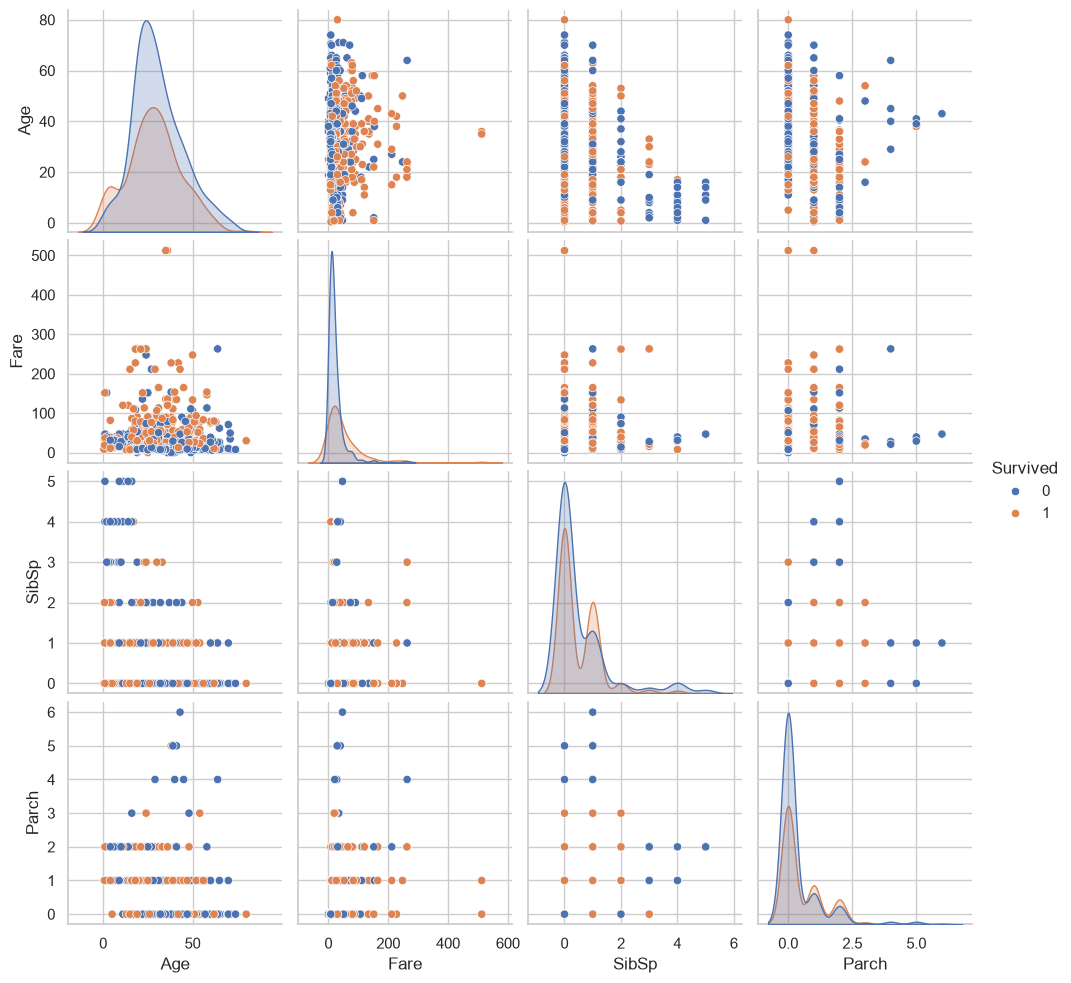

In [9]:
pair_data = df[["Age", "Fare", "SibSp", "Parch", "Survived"]].dropna()

sns.pairplot(pair_data, hue="Survived")

plt.show()

## 9. Heatmap

### Concept

A heatmap provides a visual representation of the correlation between numerical variables.

### Example

We can calculate the correlations among features such as `Age`, `Fare`, `SibSp`, `Parch`, and `Survived`.

### Why This Visualization Was Selected

A heatmap makes it easier to identify strong positive, negative, and weak correlations.

### Implementation

We calculate the correlation matrix of selected numerical variables and display it using a heatmap.

### Output

Each cell represents the correlation between two variables.

### Interpretation

Values close to 1 indicate positive correlation, values close to -1 indicate negative correlation, and values close to 0 indicate weak linear correlation.

### Insight

The heatmap helps identify numerical features that may have meaningful relationships with each other or with the target variable.

### AI/ML Relevance

Correlation analysis can help identify redundant features, possible multicollinearity, and useful numerical relationships.

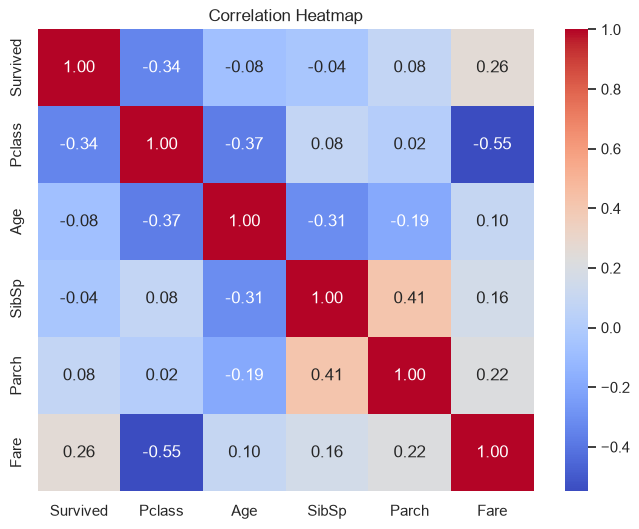

In [10]:
numerical_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

## 10. Distribution Plot

### Concept

A distribution plot combines a histogram with a density curve to provide a detailed view of a numerical variable.

### Example

We can use `Fare` to understand the overall shape of passenger fare values.

### Why This Visualization Was Selected

The `Fare` variable is numerical and may contain skewness and extreme values, so a distribution plot is useful for examining its shape.

### Implementation

We create a histogram with a KDE curve for the `Fare` variable.

### Output

The histogram shows the frequency distribution, while the density curve shows the overall shape of the distribution.

### Interpretation

A longer tail on one side may indicate skewness. Extreme values may also be visible.

### Insight

The fare distribution can help us understand whether the feature is symmetric or skewed.

### AI/ML Relevance

Highly skewed numerical features may require transformation before they are used in certain Machine Learning models.

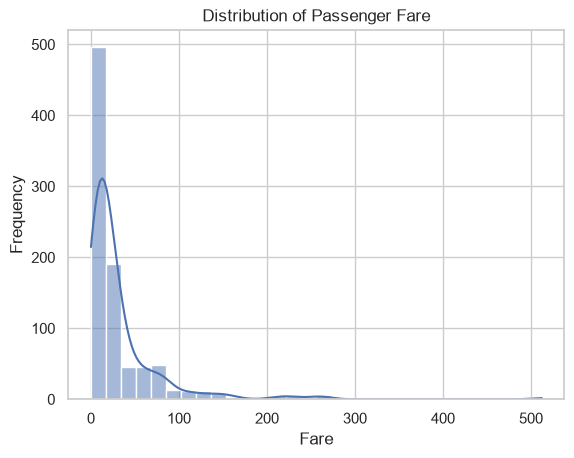

In [11]:
sns.histplot(df["Fare"], kde=True, bins=30)

plt.title("Distribution of Passenger Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

# Conclusion

This notebook used Matplotlib and Seaborn to create meaningful visualizations for the Titanic dataset.

The analysis included:

- Histogram
- Box Plot
- Bar Chart
- Count Plot
- Scatter Plot
- Line Plot
- Violin Plot
- Pair Plot
- Heatmap
- Distribution Plot

Each visualization was selected based on the type of variable or relationship being analyzed. The visualizations helped identify distributions, outliers, category frequencies, feature relationships, survival patterns, and correlations.

## Final Insight

EDA visualization makes the dataset easier to understand before Machine Learning. Instead of creating graphs only for presentation, each graph should answer a specific question about the data.

## AI/ML Relevance

The findings from visualization can support feature selection, preprocessing, outlier investigation, transformation decisions, and the overall development of a Machine Learning model.